In [2]:
import pandas as pd
df=pd.read_csv("outliers.csv")
print(df.head())

   math score  reading score  writing score  placement score  \
0          80             68             70               89   
1          71             61             85               91   
2          79             16             87               77   
3          61             77             74               76   
4          78             71             67               90   

   placement offer count  club join year  
0                      3            2019  
1                      3            2019  
2                      2            2018  
3                      2            2020  
4                      3            2019  


In [3]:
df.describe()

,math score,reading score,writing score,placement score,placement offer count,club join year
count,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000
mean,84.482759,65.896552,73.793103,82.724138,2.448276,2019.448276
std,25.973366,20.098587,17.341897,26.891178,0.631676,0.985111
min,61.000000,1.000000,12.000000,12.000000,1.000000,2018.000000
25%,74.000000,62.000000,70.000000,77.000000,2.000000,2019.000000
50%,77.000000,68.000000,78.000000,85.000000,3.000000,2019.000000
75%,80.000000,74.000000,85.000000,91.000000,3.000000,2020.000000
max,180.000000,120.000000,90.000000,180.000000,3.000000,2021.000000


In [4]:
df.isnull().sum()

math score               0
reading score            0
writing score            0
placement score          0
placement offer count    0
club join year           0
dtype: int64

/home/pict/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


<Axes: >

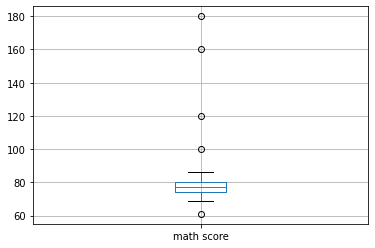

In [5]:
df.boxplot(column=['math score'])

In [9]:
Q1=df['math score'].quantile(0.25)
Q3=df['math score'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
# Identify outliers
outliers = df[(df['math score'] < lower_bound) | (df['math score'] > upper_bound)]
print(outliers)
# To get a cleaned DataFrame (non-outliers)
df_clean = df[(df['math score'] >= lower_bound) & (df['math score'] <= upper_bound)]
#print(df_clean)

    math score  reading score  writing score  placement score  \
3           61             77             74               76   
10         160             67             12               83   
21         100             77             70               91   
25         180             67             63               75   
28         120             73             71               94   

    placement offer count  club join year  
3                       2            2020  
10                      2            2020  
21                      3            2018  
25                      3            2021  
28                      3            2019  


<Axes: >

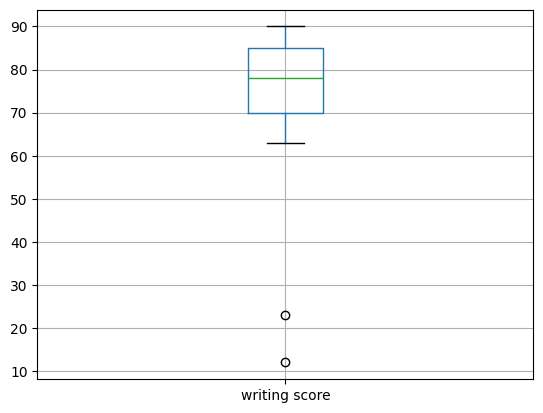

In [10]:
df.boxplot(column=['writing score'])

In [11]:
Q1=df['writing score'].quantile(0.25)
Q3=df['writing score'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print("lower_bound",lower_bound)
# Identify outliers
outliers = df[(df['writing score'] < lower_bound) | (df['writing score'] > upper_bound)]
print(outliers)

lower_bound 47.5
    math score  reading score  writing score  placement score  \
10         160             67             12               83   
17          80             74             23               76   

    placement offer count  club join year  
10                      2            2020  
17                      2            2021  


<Axes: >

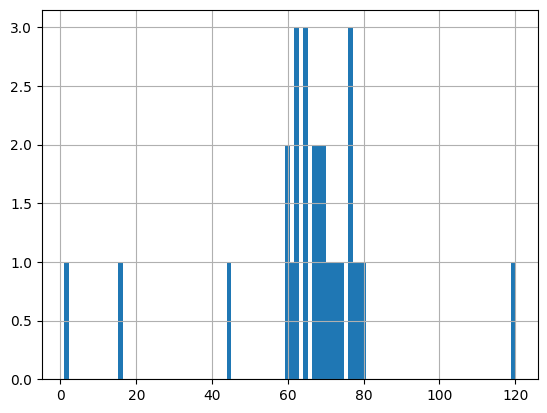

In [12]:
df['reading score'].hist(bins=100)

<Axes: xlabel='index', ylabel='reading score'>

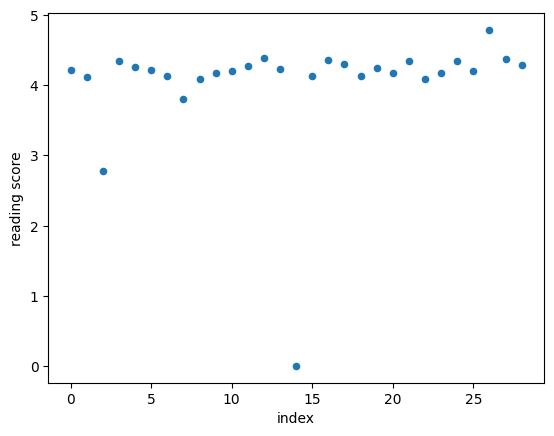

In [35]:
df = df.copy()
df.columns = df.columns.str.strip()

df_reset = df.reset_index()
df_reset.plot.scatter(y='reading score', x='index')

In [14]:
import numpy as np
from scipy import stats

In [15]:
# Calculate absolute Z-scores
z_scores = np.abs(stats.zscore(df['reading score']))
# Identify outliers (threshold > 3)
outliers = df[z_scores > 3]
# To get a cleaned DataFrame (non-outliers)
df_clean = df[z_scores <= 3] 
print(df_clean)

    math score  reading score  writing score  placement score  \
0           80             68             70               89   
1           71             61             85               91   
2           79             16             87               77   
3           61             77             74               76   
4           78             71             67               90   
5           73             68             90               80   
6           77             62             70               35   
7           74             45             80               12   
8           76             60             79               77   
9           75             65             85               87   
10         160             67             12               83   
11          79             72             88              180   
12          80             80             78               94   
13          78             69             71               90   
15          78           

In [20]:
df['math score'] = np.clip(df['math score'], lower_bound, upper_bound)
print("Data after Capping Outliers:\n", df)

Data after Capping Outliers:
     math score  reading score  writing score  placement score  \
0         80.0             68             70               89   
1         71.0             61             85               91   
2         79.0             16             87               77   
3         61.0             77             74               76   
4         78.0             71             67               90   
5         73.0             68             90               80   
6         77.0             62             70               35   
7         74.0             45             80               12   
8         76.0             60             79               77   
9         75.0             65             85               87   
10       107.5             67             12               83   
11        79.0             72             88              180   
12        80.0             80             78               94   
13        78.0             69             71               9

In [21]:
skewness = df['placement score'].skew()
print(skewness)

0.7041663498903222


In [22]:
df['placement score']=np.log(df['placement score'])
skewness = df['placement score'].skew()
print(skewness)

-2.7080663064299175


In [23]:
df['placement score']=np.sqrt(df['placement score'])
skewness = df['placement score'].skew()
print(skewness)

-3.0433550823669315


In [24]:
skewness = df['reading score'].skew()
print(skewness)

-1.1183350125212508


In [25]:
df['reading score']=np.log(df['reading score'])
skewness = df['reading score'].skew()
print(skewness)

-4.384940094680647


In [29]:
df['reading score'] = pd.to_numeric(df['reading score'], errors='coerce')
df['reading score']=1/df['reading score']
skewness = df['reading score'].skew()
print(skewness)

-4.384940094680647
